#Clustering and DCGAN With CIFAR-10

On this code, We'll do a clustering of CIFAR-10 by image classes, and then a DCGAN of these Images, With a Encoder and a Discriminator, create artificial images starting from these pre-existing ones.

##1) Importing Frameworks and Libraries

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import torchvision.utils as vutils

##2) Clustering

Now, we'll do a clustering by image classes, using PCA, T-SNE and UMAP.

First, we'll do a clusterring of all classes.

Usando dispositivo: cuda


100%|██████████| 170M/170M [00:02<00:00, 74.0MB/s]



Iniciando o treinamento do Autoencoder Melhorado...
Época [1/20], Loss: 0.0081
Época [2/20], Loss: 0.0068
Época [3/20], Loss: 0.0054
Época [4/20], Loss: 0.0053
Época [5/20], Loss: 0.0050
Época [6/20], Loss: 0.0049
Época [7/20], Loss: 0.0054
Época [8/20], Loss: 0.0045
Época [9/20], Loss: 0.0050
Época [10/20], Loss: 0.0047
Época [11/20], Loss: 0.0060
Época [12/20], Loss: 0.0043
Época [13/20], Loss: 0.0049
Época [14/20], Loss: 0.0049
Época [15/20], Loss: 0.0042
Época [16/20], Loss: 0.0048
Época [17/20], Loss: 0.0043
Época [18/20], Loss: 0.0047
Época [19/20], Loss: 0.0045
Época [20/20], Loss: 0.0040
Treinamento concluído.

Embeddings extraídos. Dimensão: (5000, 128)
Calculando visualizações...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


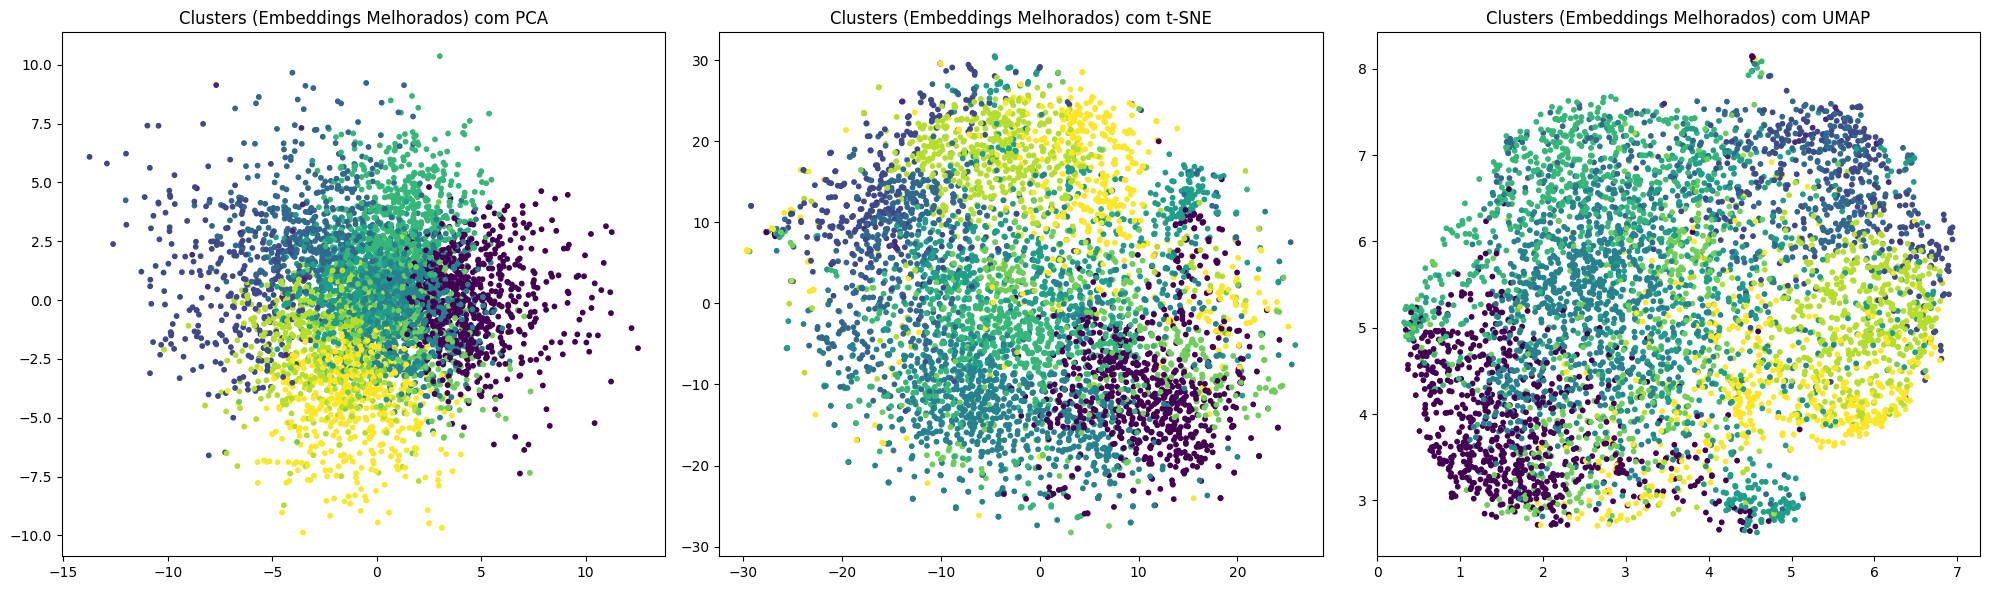

In [ ]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- PART 1: DATA PREPARATION AND TRAINING THE IMPROVED AUTOENCODER ---

# Load CIFAR-10 data
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

# Size of the embedding vector we want
EMBEDDING_DIM = 128

# Define the new Autoencoder architecture
class AdvancedAutoencoder(nn.Module):
    def __init__(self):
        super(AdvancedAutoencoder, self).__init__()
        # --- Encoder ---
        self.encoder_conv = nn.Sequential(
            # Input: 3 x 32 x 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2), # -> 64 x 16 x 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2, 2)  # -> 128 x 8 x 8
        )
        self.encoder_linear = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, EMBEDDING_DIM)
        )

        # --- Decoder ---
        self.decoder_linear = nn.Sequential(
            nn.Linear(EMBEDDING_DIM, 128 * 8 * 8),
            nn.ReLU()
        )
        self.decoder_conv = nn.Sequential(
            # Input: 128 x 8 x 8
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ConvTranspose2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),

            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ConvTranspose2d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),

            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid() # Output between 0 and 1
        )

    def forward(self, x):
        embedding = self.encoder_conv(x)
        embedding = self.encoder_linear(embedding)

        reconstruction = self.decoder_linear(embedding)
        reconstruction = reconstruction.view(-1, 128, 8, 8) # Unflatten
        reconstruction = self.decoder_conv(reconstruction)
        return reconstruction

    def get_embedding(self, x):
        with torch.no_grad():
            x = self.encoder_conv(x)
            embedding = self.encoder_linear(x)
        return embedding

# Instantiate and train the new model
model = AdvancedAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 20 # Increase for better results (e.g., 30-50)

print("\nStarting Improved Autoencoder training...")
for epoch in range(epochs):
    for data in train_loader:
        img, _ = data
        img = img.to(device)
        output = model(img)
        loss = criterion(output, img)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
print("Training completed.")


# --- PARTS 2, 3, and 4: EXTRACTION, CLUSTERING, AND VISUALIZATION ---

# Extract embeddings
subset_loader = DataLoader(train_dataset, batch_size=5000, shuffle=False)
images, original_labels = next(iter(subset_loader))
images = images.to(device)

model.eval()
embeddings = model.get_embedding(images)
embeddings_np = embeddings.cpu().numpy()
print(f"\nEmbeddings extracted. Dimensions: {embeddings_np.shape}")

# Normalize and Cluster
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_np)

kmeans = MiniBatchKMeans(n_clusters=10, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_scaled)

# Dimensionality reduction for visualization
print("Calculating visualizations...")
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(embeddings_scaled)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embeddings_tsne = tsne.fit_transform(embeddings_scaled)

reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_umap = reducer.fit_transform(embeddings_scaled)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes[0].scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], c=cluster_labels, cmap='viridis', s=10)
axes[0].set_title('Clusters (Improved Embeddings) with PCA')
axes[1].scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], c=cluster_labels, cmap='viridis', s=10)
axes[1].set_title('Clusters (Improved Embeddings) with t-SNE')
axes[2].scatter(embeddings_umap[:, 0], embeddings_umap[:, 1], c=cluster_labels, cmap='viridis', s=10)
axes[2].set_title('Clusters (Improved Embeddings) with UMAP')

plt.tight_layout()
plt.show()

Now, We'll select three classes and cluster them.

Usando dispositivo: cuda
Número de amostras após filtrar para 3 classes: 15000

Iniciando o treinamento do Autoencoder nas 4 classes selecionadas...
Época [1/20], Loss: 0.0159
Época [2/20], Loss: 0.0094
Época [3/20], Loss: 0.0084
Época [4/20], Loss: 0.0070
Época [5/20], Loss: 0.0071
Época [6/20], Loss: 0.0081
Época [7/20], Loss: 0.0070
Época [8/20], Loss: 0.0062
Época [9/20], Loss: 0.0065
Época [10/20], Loss: 0.0061
Época [11/20], Loss: 0.0064
Época [12/20], Loss: 0.0069
Época [13/20], Loss: 0.0063
Época [14/20], Loss: 0.0054
Época [15/20], Loss: 0.0044
Época [16/20], Loss: 0.0074
Época [17/20], Loss: 0.0054
Época [18/20], Loss: 0.0049
Época [19/20], Loss: 0.0046
Época [20/20], Loss: 0.0059
Treinamento concluído.

Embeddings extraídos. Dimensão: (15000, 128)
Calculando visualizações...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


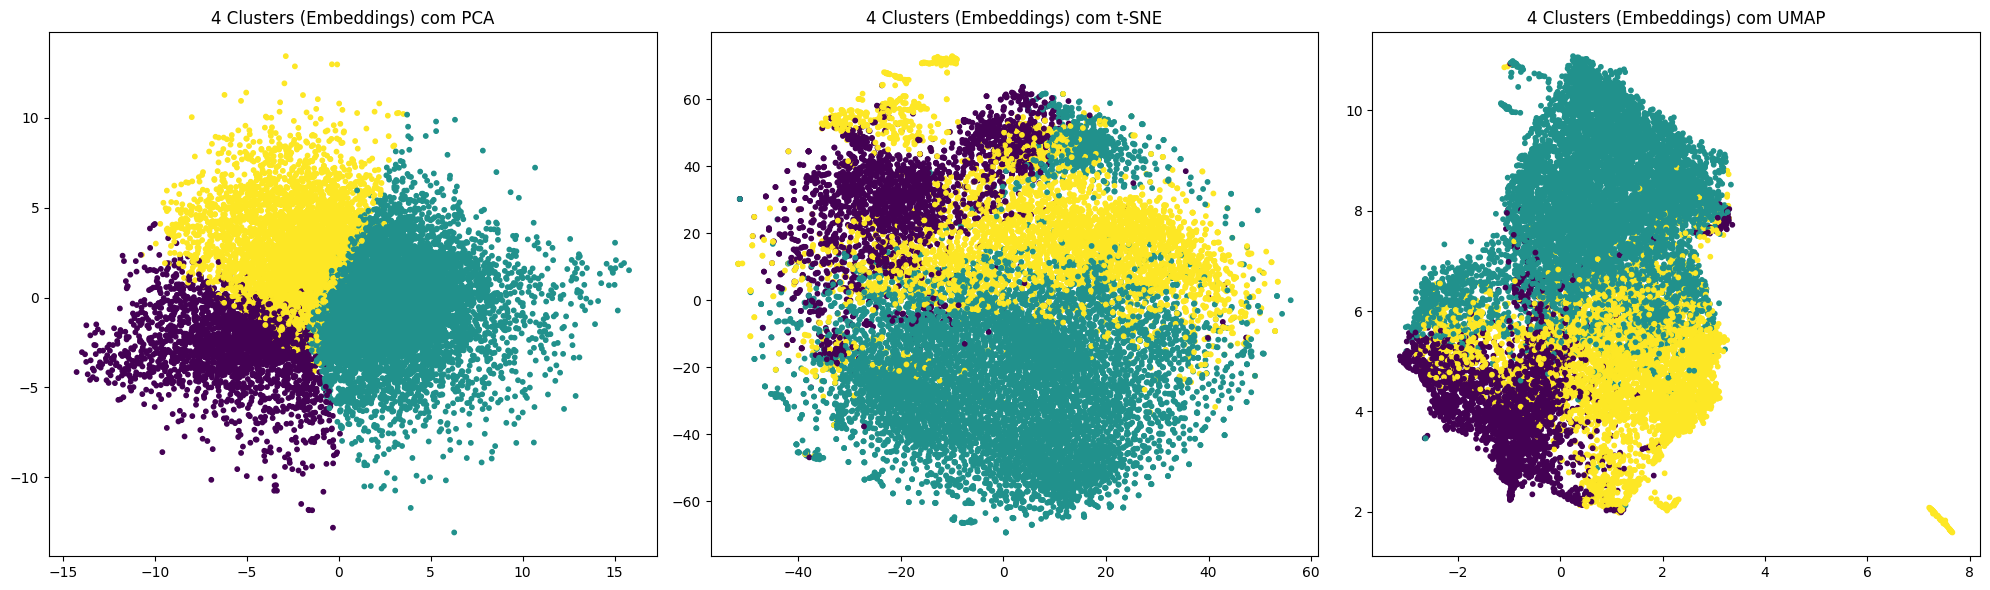

In [ ]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# --- DATA PREPARATION AND AUTOENCODER TRAINING ---

# Load full CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_dataset_full = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)


# --- Filter the dataset for 3 specific classes ---
TARGET_CLASSES = [0, 1, 2] # Example: Airplane, Automobile, Bird

# Convert targets to a NumPy array for easier filtering
targets_np = np.array(train_dataset_full.targets)
mask = np.isin(targets_np, TARGET_CLASSES)

# Filter data and labels
filtered_data = train_dataset_full.data[mask]
filtered_targets = targets_np[mask]

print(f"Number of samples after filtering for 3 classes: {len(filtered_data)}")

# Convert filtered data to PyTorch tensors
# Normalize to [0, 1] and permute dimensions to (C, H, W)
filtered_data_tensor = torch.tensor(filtered_data, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
filtered_targets_tensor = torch.tensor(filtered_targets, dtype=torch.long)

# Create a new TensorDataset and DataLoader with filtered data
filtered_dataset = TensorDataset(filtered_data_tensor, filtered_targets_tensor)
train_loader = DataLoader(filtered_dataset, batch_size=128, shuffle=True)


# --- Autoencoder Architecture ---
EMBEDDING_DIM = 128

class AdvancedAutoencoder(nn.Module):
    def __init__(self):
        super(AdvancedAutoencoder, self).__init__()
        # Encoder
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.MaxPool2d(2, 2), # -> 64 x 16 x 16
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(128),
            nn.MaxPool2d(2, 2)  # -> 128 x 8 x 8
        )
        self.encoder_linear = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, EMBEDDING_DIM)
        )

        # Decoder
        self.decoder_linear = nn.Sequential(
            nn.Linear(EMBEDDING_DIM, 128 * 8 * 8),
            nn.ReLU()
        )
        self.decoder_conv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ConvTranspose2d(128, 64, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(64),
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.ConvTranspose2d(64, 32, kernel_size=3, padding=1), nn.ReLU(), nn.BatchNorm2d(32),
            nn.Conv2d(32, 3, kernel_size=3, padding=1),
            nn.Sigmoid() # Output pixels scaled between 0 and 1
        )

    def forward(self, x):
        embedding = self.encoder_conv(x)
        embedding = self.encoder_linear(embedding)
        reconstruction = self.decoder_linear(embedding)
        reconstruction = reconstruction.view(-1, 128, 8, 8) # Reshape for convolutions
        reconstruction = self.decoder_conv(reconstruction)
        return reconstruction

    def get_embedding(self, x):
        with torch.no_grad():
            x = self.encoder_conv(x)
            embedding = self.encoder_linear(x)
        return embedding

# Instantiate and train the model on the filtered dataset
model = AdvancedAutoencoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 20

print("\nStarting Autoencoder training on the selected classes...")
for epoch in range(epochs):
    for img, _ in train_loader:
        img = img.to(device)
        output = model(img)
        loss = criterion(output, img)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')
print("Training completed.")


# --- EXTRACTION, CLUSTERING, AND VISUALIZATION ---

# Extract embeddings for all samples in the filtered dataset
all_filtered_loader = DataLoader(filtered_dataset, batch_size=len(filtered_dataset), shuffle=False)
images, original_labels = next(iter(all_filtered_loader))
images = images.to(device)

model.eval()
embeddings = model.get_embedding(images)
embeddings_np = embeddings.cpu().numpy()
print(f"\nEmbeddings extracted. Dimensions: {embeddings_np.shape}")

# Normalize and Cluster
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings_np)

# Set n_clusters=3 to match our TARGET_CLASSES
kmeans = MiniBatchKMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings_scaled)

# Dimensionality reduction for visualization
print("Calculating visualizations...")
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(embeddings_scaled)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
embeddings_tsne = tsne.fit_transform(embeddings_scaled)

reducer = umap.UMAP(n_components=2, random_state=42)
embeddings_umap = reducer.fit_transform(embeddings_scaled)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(embeddings_pca[:, 0], embeddings_pca[:, 1], c=cluster_labels, cmap='viridis', s=10)
axes[0].set_title('3 Clusters (Embeddings) with PCA')

axes[1].scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], c=cluster_labels, cmap='viridis', s=10)
axes[1].set_title('3 Clusters (Embeddings) with t-SNE')

axes[2].scatter(embeddings_umap[:, 0], embeddings_umap[:, 1], c=cluster_labels, cmap='viridis', s=10)
axes[2].set_title('3 Clusters (Embeddings) with UMAP')

plt.tight_layout()
plt.show()

##3) Data Loading

In [ ]:
# =============================================================================
# PART 2: DATA FILTERING FOR THE GAN
# =============================================================================

# Choose the specific cluster to train the GAN on
GAN_TARGET_CLUSTER = 1
print(f"\nSelecting images from cluster {GAN_TARGET_CLUSTER} for DCGAN training...")

# Create a mask to select only the data belonging to the target cluster
mask = (cluster_labels == GAN_TARGET_CLUSTER)
gan_data = images[mask].cpu() # Move the filtered data back to CPU

print(f"Number of images in the selected cluster: {gan_data.shape[0]}")

# Create a new DataLoader containing only the cluster-specific data
gan_dataset = TensorDataset(gan_data)
gan_loader = DataLoader(gan_dataset, batch_size=64, shuffle=True)


Selecionando imagens do cluster 1 para o treinamento do DCGAN...
Número de imagens no cluster selecionado: 9238


##4) Modeling

In [ ]:
# =============================================================================
# PART 3: DCGAN DEFINITION AND TRAINING (MNIST NOTEBOOK LOGIC)
# =============================================================================

# Parameters adapted for CIFAR-10
nz = 256        # Size of latent vector z
ngf = 64       # Size of feature maps in the generator
ndf = 64       # Size of feature maps in the discriminator
nc = 3         # Number of color channels (RGB)
image_size = 32 # Image size
lr = 0.0002    # Learning rate
beta1 = 0.5    # Beta1 hyperparameter for Adam optimizers
epochs = 2000  # Increase for better results (e.g., 100+)

# Weight initialization function (from the MNIST notebook)
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# Generator - Adapted for 32x32x3
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Input is Z, going into a convolution
            nn.ConvTranspose2d(nz, ngf * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # State size: (ngf*4) x 4 x 4
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # State size: (ngf*2) x 8 x 8
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # State size: (ngf) x 16 x 16
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # Final state size: (nc) x 32 x 32
        )

    def forward(self, input):
        return self.main(input)

# Discriminator - Adapted for 32x32x3
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input is (nc) x 32 x 32
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf) x 16 x 16
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf*2) x 8 x 8
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # State size: (ndf*4) x 4 x 4
            nn.Conv2d(ndf * 4, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

# Instantiate networks
netG = Generator().to(device)
netD = Discriminator().to(device)

# Apply weights_init function to randomly initialize weights
netG.apply(weights_init)
netD.apply(weights_init)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (9): Sigmoid()
  )
)

##5) Optimization

In [ ]:
# Loss and Optimizers
criterion = nn.BCELoss() # Binary Cross Entropy Loss for adversarial training
fixed_noise = torch.randn(64, nz, 1, 1, device=device) # Fixed noise for progress visualization
real_label = 1.
fake_label = 0.

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

##6) Training

In [ ]:
# DCGAN Training Loop
print("\nStarting DCGAN training...")
img_list = []
G_losses = []
D_losses = []

for epoch in range(epochs):
    for i, data in enumerate(gan_loader, 0):
        # --- (1) Update the Discriminator Network ---
        netD.zero_grad()

        # Train with real batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)

        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()

        # Train with fake batch
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(fake_label)

        # We detach the fake batch to avoid calculating gradients for netG here
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()

        errD = errD_real + errD_fake
        optimizerD.step()

        # --- (2) Update the Generator Network ---
        netG.zero_grad()

        # For the generator, we want the discriminator to think the fake images are real
        label.fill_(real_label)
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

        # Save losses for later plotting
        G_losses.append(errG.item())
        D_losses.append(errD.item())

    print(f'Epoch [{epoch+1}/{epochs}], Loss_D: {errD.item():.4f}, Loss_G: {errG.item():.4f}')

    # Save generated images at each epoch for visualization
    with torch.no_grad():
        fake_imgs = netG(fixed_noise).detach().cpu()
        img_list.append(vutils.make_grid(fake_imgs, padding=2, normalize=True))

print("DCGAN training completed.")


Iniciando o treinamento do DCGAN...
Época [1/2000], Loss_D: 0.5430, Loss_G: 3.0981
Época [2/2000], Loss_D: 0.3366, Loss_G: 5.2405
Época [3/2000], Loss_D: 0.4456, Loss_G: 2.6593
Época [4/2000], Loss_D: 0.2284, Loss_G: 4.2018
Época [5/2000], Loss_D: 0.4788, Loss_G: 5.5649
Época [6/2000], Loss_D: 0.7055, Loss_G: 4.8760
Época [7/2000], Loss_D: 0.6347, Loss_G: 1.4402
Época [8/2000], Loss_D: 1.2139, Loss_G: 5.4759
Época [9/2000], Loss_D: 0.8104, Loss_G: 3.9396
Época [10/2000], Loss_D: 0.5574, Loss_G: 2.7614
Época [11/2000], Loss_D: 0.8258, Loss_G: 1.8907
Época [12/2000], Loss_D: 0.8164, Loss_G: 1.7948
Época [13/2000], Loss_D: 0.6512, Loss_G: 3.0069
Época [14/2000], Loss_D: 0.5480, Loss_G: 2.0975
Época [15/2000], Loss_D: 0.8473, Loss_G: 2.3822
Época [16/2000], Loss_D: 0.6512, Loss_G: 1.2599
Época [17/2000], Loss_D: 0.5138, Loss_G: 3.6304
Época [18/2000], Loss_D: 0.5173, Loss_G: 3.6519
Época [19/2000], Loss_D: 0.5225, Loss_G: 1.9506
Época [20/2000], Loss_D: 0.4403, Loss_G: 3.3140
Época [21/20

##7) Visualization

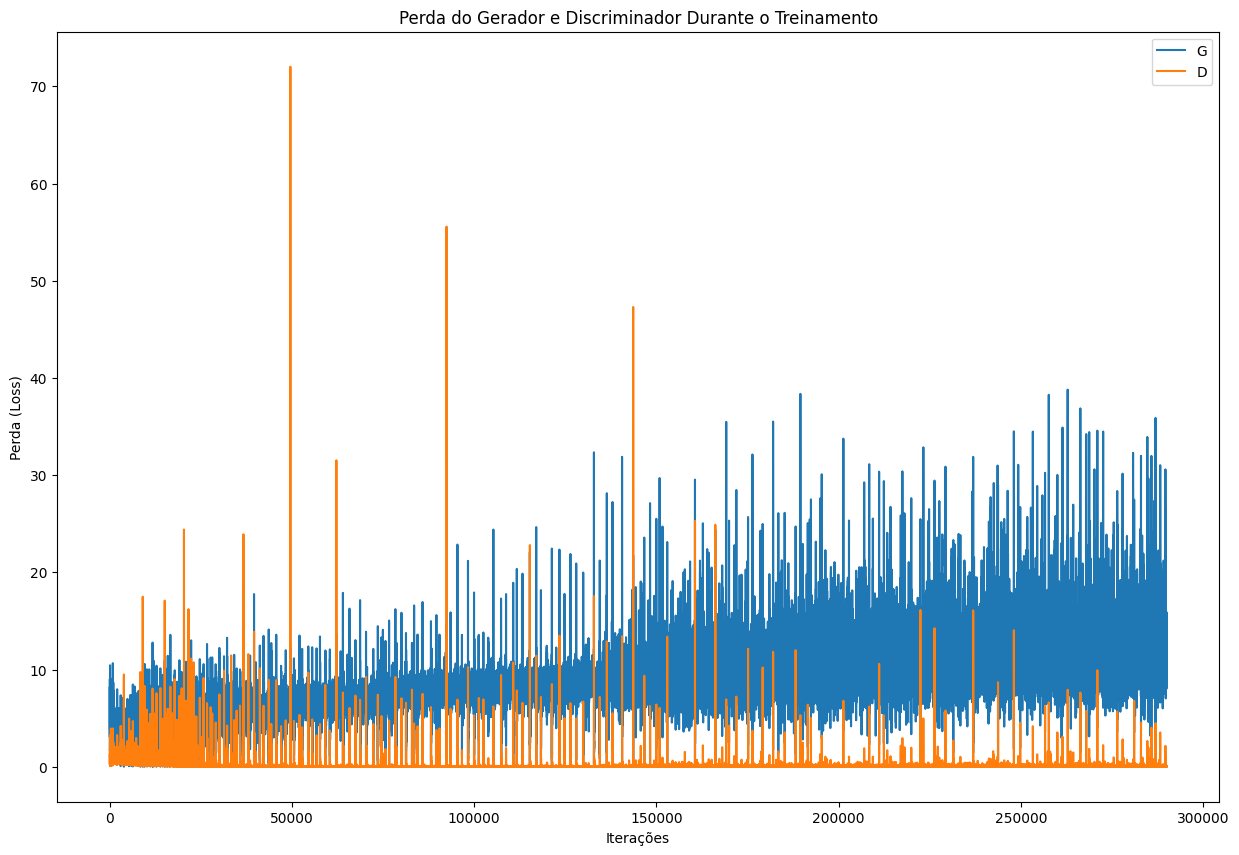

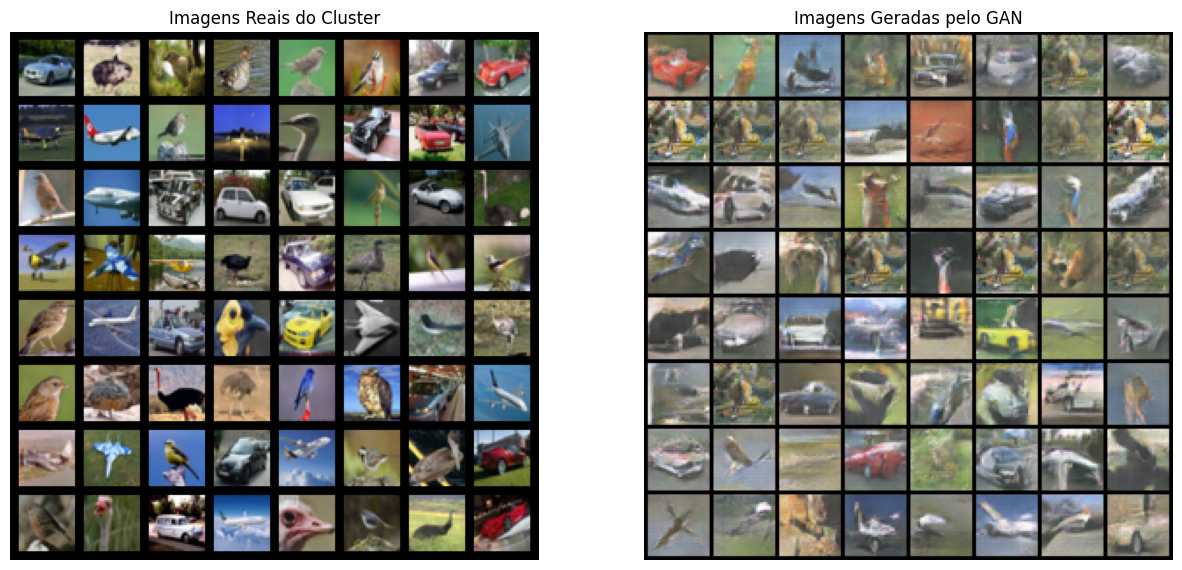

In [ ]:
# =============================================================================
# PART 4: VISUALIZATION OF GAN RESULTS
# =============================================================================

# Plot training losses
plt.figure(figsize=(15, 10))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="Generator")
plt.plot(D_losses, label="Discriminator")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot real images vs. generated images
real_batch = next(iter(gan_loader))
plt.figure(figsize=(15, 15))

# Real images from the specific cluster
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Real Cluster Images")
# Displaying the first 64 images from the real batch
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(), (1, 2, 0)))

# Final generated images from the training loop
plt.subplot(1, 2, 2)
plt.axis("off")
plt.title("GAN Generated Images")
# Displaying the last grid of images saved in img_list
plt.imshow(np.transpose(img_list[-1], (1, 2, 0)))
plt.show()